# Предобработка данных

## Цель работы

Познакомиться с основными задачами и приемами предварительного анализа и обработки данных для целей машинного обучения

Предварительная обработка данных является неотъемлемым этапом машинного обучения, поскольку качество данных и полезная информация, которую можно извлечь из них, напрямую влияют на способность нашей модели к обучению; поэтому чрезвычайно важно, чтобы мы предварительно обработали наши данные, прежде чем вводить их в нашу модель.

## Содержание работы

1. Загрузите данные о пассажирах Титаника и познакомьтесь со структурой датасета.
1. Проведите анализ и визуализацию каждого признака датасета. Сделайте вывод о виде распределения и шкале каждого признака.
1. Проанализируйте влияние каждого признака на целевую переменную. Проиллюстрируйте ее графиками.
1. Исследуйте и исправьте при необходимости пропущенные значения в датасете.
1. Преобразуйте категориальные признаки в численные самым подходящим способом.

## Методические указания

### Подготовка и загрузка данных

Для полноценной работы с регрессионным анализом данных нам потребуются следующие библиотеки языка Python:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')

Для начала считаем данные из csv-файла:

In [2]:
training_set = pd.read_csv('data/titanic.csv')
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Результат работы функции - предпросмотр загруженных данных. Рассмотрим внимательнее, что содержится в данном датасете. Ниже представлена краткая информация о каждом из столбцов датасета:

**PassengerId**: Уникальный индекс/номер строки. Начинается с 1 (для первой строки) и увеличивается на 1 для каждой следующей. Рассматриваем его как идентификатор строки и, что логично, идентификатор пассажира (т.к. для каждого пассажира в датасете представлена только одна строка).

**Survived**: Признак, показывающий был ли спасен данный пассажир или нет. 1 означает, что удалось выжить, и 0 - не удалось спастись.

**Pclass**: Класс билета. 1 - означает Первый класс билета. 2 - означает Второй класс билета. 3 - означает Третий класс билета.

**Name**: Имя пассажира. Имя также может содержать титулы и обращения. "Mr" для мужчин. "Mrs" для женщин. "Miss" для девушек (тут имеется в виду что для тех, кто не замужем, так было принято, да и сейчас тоже, говорить в западном обществе). "Master" для юношей.

**Sex**: Пол пассажира. Либо мужчины (=Male) либо женщины (=Female).

**Age**: Возраст пассажира. "NaN" значения в этой колонке означают, что возраст данного пассажира отсутствует/неизвестен/или не был записан в датасет.

**SibSp**: Количество братьев/сестер или супругов, путешествующих с каждым пассажиром.

**Parch**: Количество родителей детей (Number of parents of children travelling with each passenger).

**Ticket**: Номер билета.

**Fare**: Сумма, которую заплатил пассажир за путешествие.

**Cabin**: Номер каюты пассажира. "NaN" значения в этой колонке указывает на то, что номер каюты данного пассажира не был записан.

**Embarked**: Порт отправления данного пассажира.

.describe() отобразит различные величины, такие как количество, среднее, среднеквадратичное отклонение и т.д. для численных типов данных.

Это может быть полезным для понимания распределения значений по датасету и статистики, особенно когда нет возможности просмотреть все записи в виду огромного их количества

In [3]:
training_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Очень часто во множестве данных будут присутствовать отсутствующие данные. Используем метод isnull. Результатом вызова данного метода является логическое значение, указывающее, действительно ли значение, переданное в аргумент, отсутствует. «Истина» ( True ) означает, что значение является отсутствующим значением, а «Ложь» ( False ) означает, что значение не является отсутствующим.

.describe(include = ['O']) отобразит статистики (descriptive statistics) объектного типа. Это нужно для нечисловых данных, когда нельзя просто посчитать максимумы/среднее/и пр. для данных. Мы можем отнести такие данные к категориальному виду

In [4]:
training_set.describe(include=['O'])

/tmp/ipykernel_2474/2198228790.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  training_set.describe(include=['O'])


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


Видно, что существуют дубликаты номеров билетов Ticket и переиспользуются каюты Cabins (уникальных записей (unique) меньше, чем общего количества). Самый большой порядок дубликата билета - "347082". Он повторился 7 раз. Аналогично, наибольшее число людей, занимающих одну и ту же каюту - 4. Они используют каюты "B96 B98".
Также можно заметить, что 644 человека отбыли из порта "S".
Среди 891 записей, 577 были мужчины (Male), оставшиеся - женщины (Female).

### Описание каждого признака

Гистограмма распределения признаков

In [5]:
def custom_hist(training_set, title,  xlabel, ylabel='Количество', bins=None):
    figsize = (20,6)
    plt.figure(figsize=figsize)
    plt.grid(True)
    plt.title(title)
    plt.hist(training_set, training_set.max().astype(int) if bins is None else bins)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

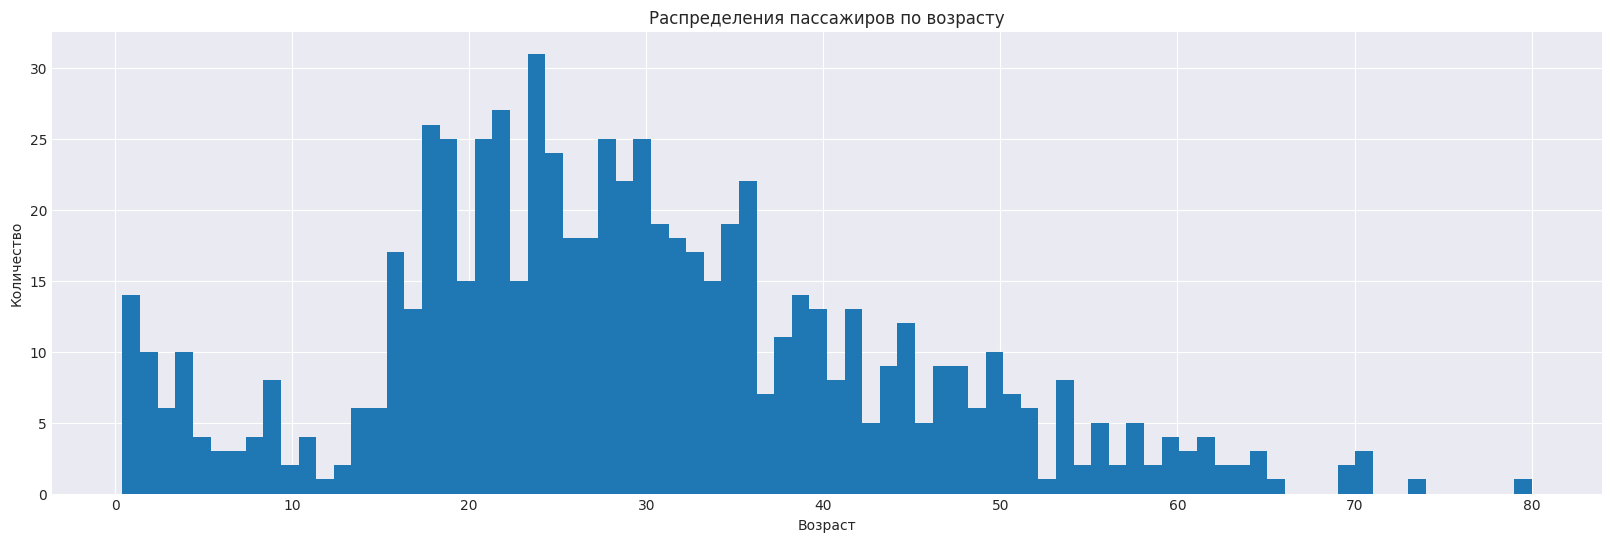

In [6]:
custom_hist(training_set["Age"], 'Распределения пассажиров по возрасту', 'Возраст')

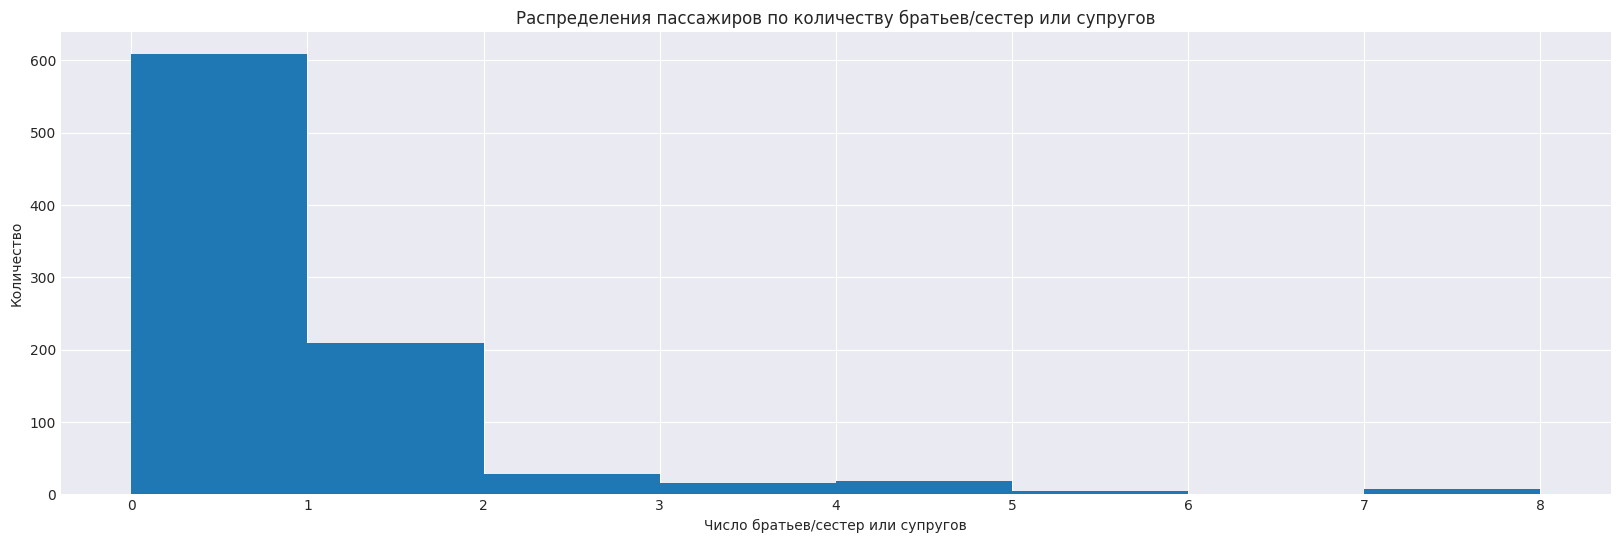

In [7]:
custom_hist(training_set["SibSp"], 'Распределения пассажиров по количеству братьев/сестер или супругов', 
  'Число братьев/сестер или супругов')

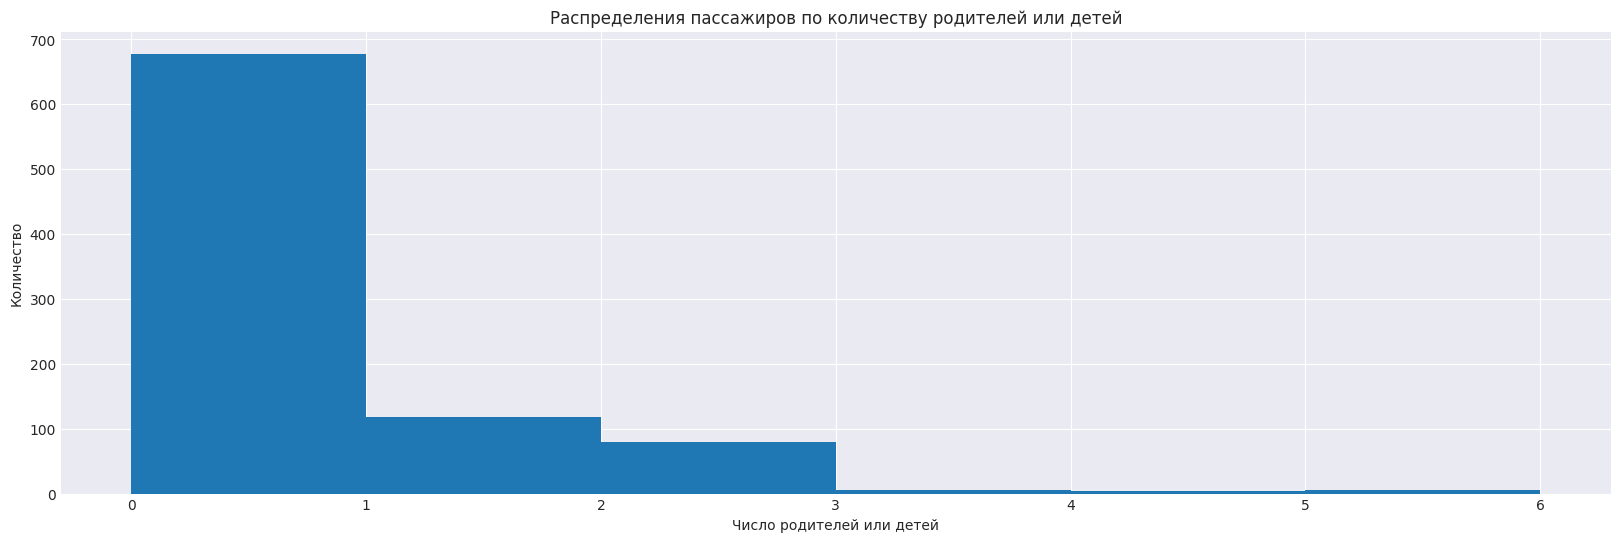

In [8]:
custom_hist(training_set["Parch"], 'Распределения пассажиров по количеству родителей или детей', 
  'Число родителей или детей')

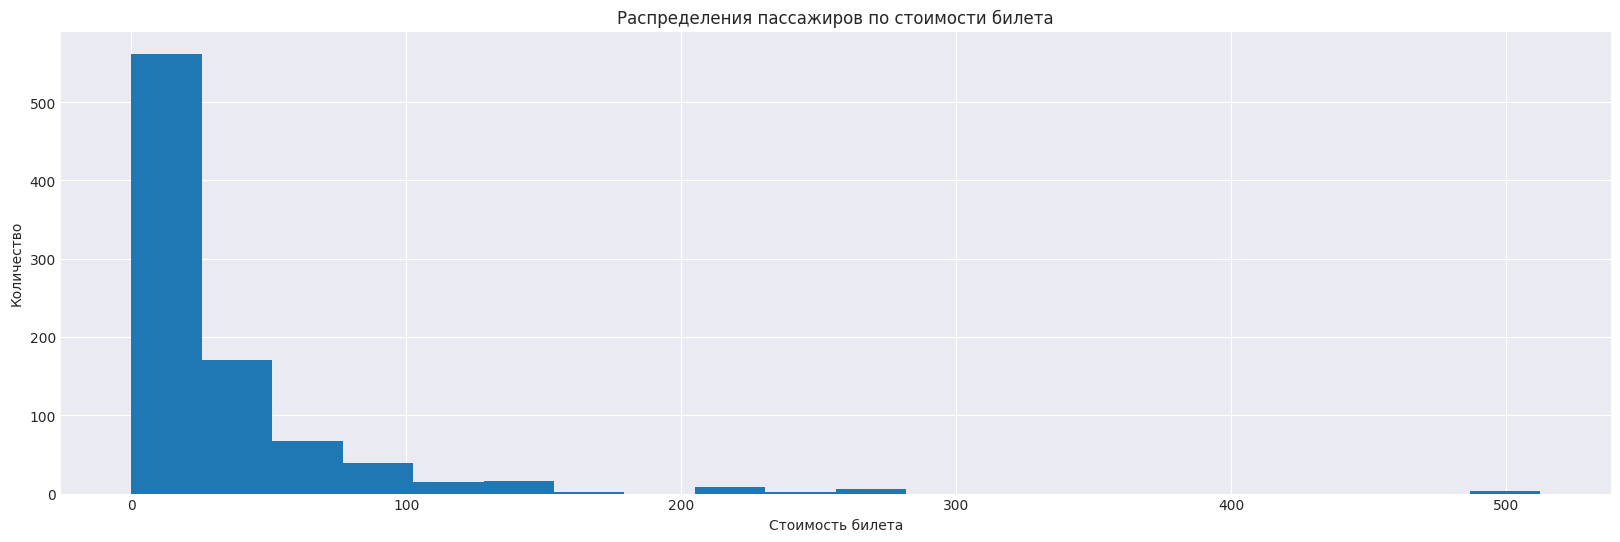

In [9]:
custom_hist(training_set["Fare"], 'Распределения пассажиров по стоимости билета', 
  'Стоимость билета', bins=20)

Далее проанализируем возраст людей, это мы сделаем с помощью графика распределения. На графике мы видим, что средний возраст пассажиров составляет 20-35 лет.

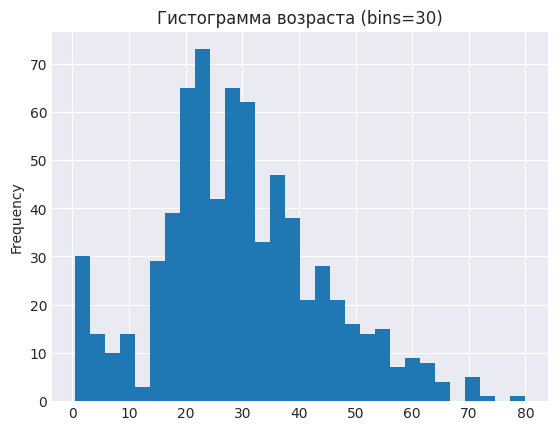

In [10]:
training_set['Age'].plot.hist(bins=30)
plt.title('Гистограмма возраста (bins=30)')
plt.show()

Проведем исследования столбца SibSp, означающий сестра,братья/супруги. Из графика мы видим, что большинство не имело братьев и сестер, а так же супругов, следующий столбец -1- учитывает супругов

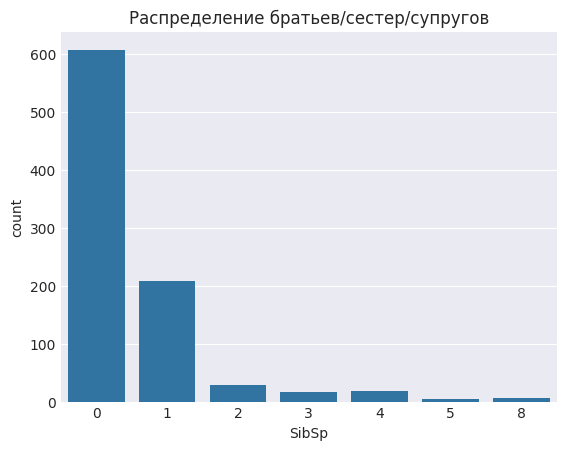

In [11]:
sns.countplot(x='SibSp', data=training_set)
plt.title('Распределение братьев/сестер/супругов')
plt.show()

Следующий столбец который будем исследовать - Fare, обозначает сколько люди платили за билет.

In [12]:
training_set['Fare'].head()

0     7.2500
1    71.2833
2     7.9250
3    53.1000
4     8.0500
Name: Fare, dtype: float64

Построим гистограмму:

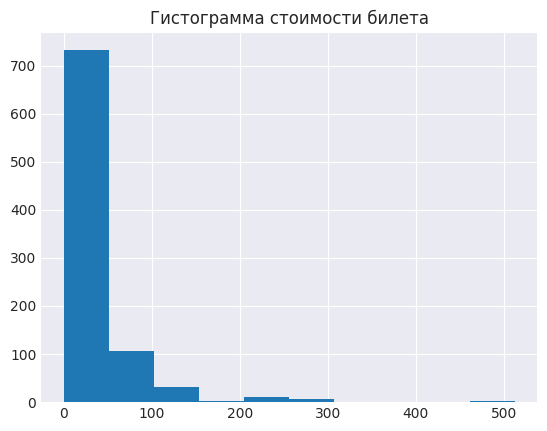

In [13]:
training_set['Fare'].hist()
plt.title('Гистограмма стоимости билета')
plt.show()

Из этого графика мы видим, что наибольшее распределение от 0 до 150, рассмотрим этот диапазон более подробно. Из графика мы видим, что наибольшее количество билетов были по цене до 50. Это действительно так, так как мы видим из данных, что большинство пассажиров было из третьего класса.

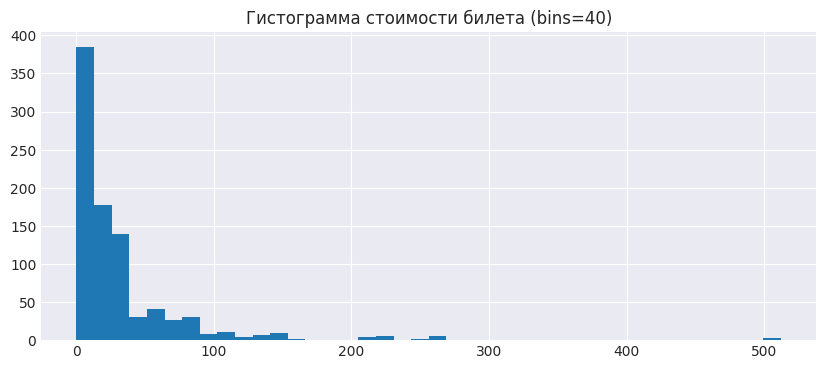

In [14]:
training_set['Fare'].hist(bins=40, figsize=(10,4))
plt.title('Гистограмма стоимости билета (bins=40)')
plt.show()

### Описание вида совместного распределения

Установим соотношение выживших и не выживших

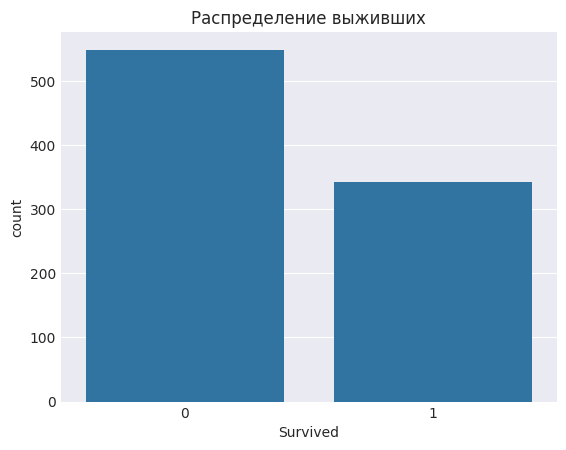

In [15]:
sns.countplot(x='Survived', data=training_set)
plt.title('Распределение выживших')
plt.show()

Отобразим пол выживших и не выживших. На графике мы видим, что среди не выживших большинство было мужчин, в выживших наоборот больше было женщин

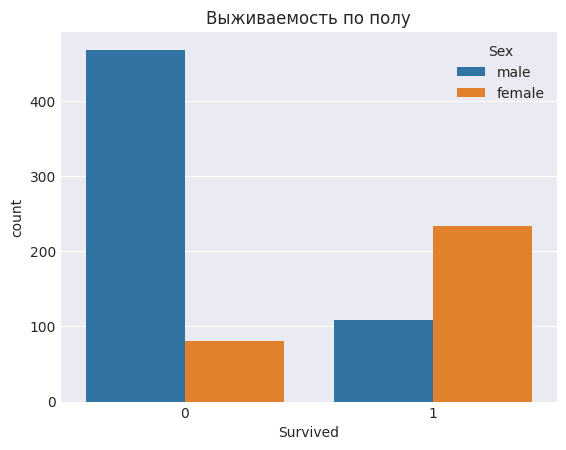

In [16]:
sns.countplot(x='Survived', data=training_set, hue='Sex')
plt.title('Выживаемость по полу')
plt.show()

В параметре hue мы можем использовать другой столбец, например класс пассажира  Pclass, и посмотреть как это соотносится с количеством выживших. Проанализировав полученный график, можно сказать, что из не выживших было больше людей третьего класса

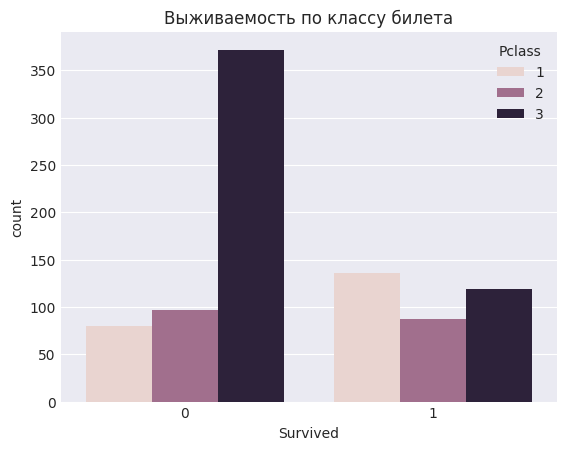

In [17]:
sns.countplot(x='Survived', data=training_set, hue='Pclass')
plt.title('Выживаемость по классу билета')
plt.show()

Создадим boxplot, передадим три параметра, класс пассажира, возраст, датасет. Из полученного графика можно сделать вывод, что средний возраст пассажиров первого класса больше чем средний возраст пассажиров второго класса, и соответственно средний возраст пассажиров второго класса больше чем средний возраст пассажиров третьего класса. Мы можем использовать эти среднии значения для того что бы вставлять эти значения там где они отсутствуют, основываясь на классе.

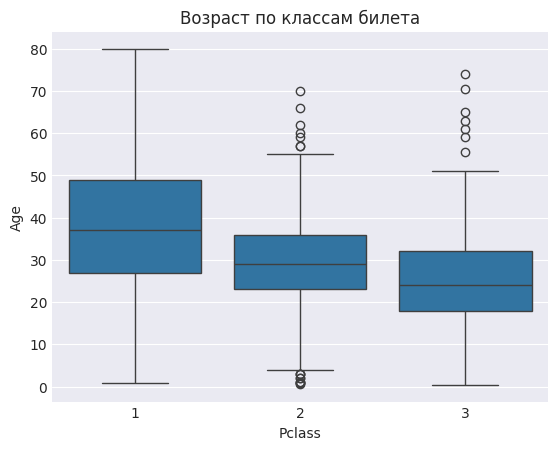

In [18]:
sns.boxplot(x='Pclass', y='Age', data=training_set)
plt.title('Возраст по классам билета')
plt.show()

В процессе анализа данных мы попробуем увидеть зависимости целевого признака от остальных признаков и остальных признаков между собой, чтобы избежать мультиколлинеарности и выбрать признаки, которые не имеют значения и которые стоит удалить.

Для признаков class, sex, sib_sp, par_ch, embarked визуализируем доли выживших для каждого значения признака:

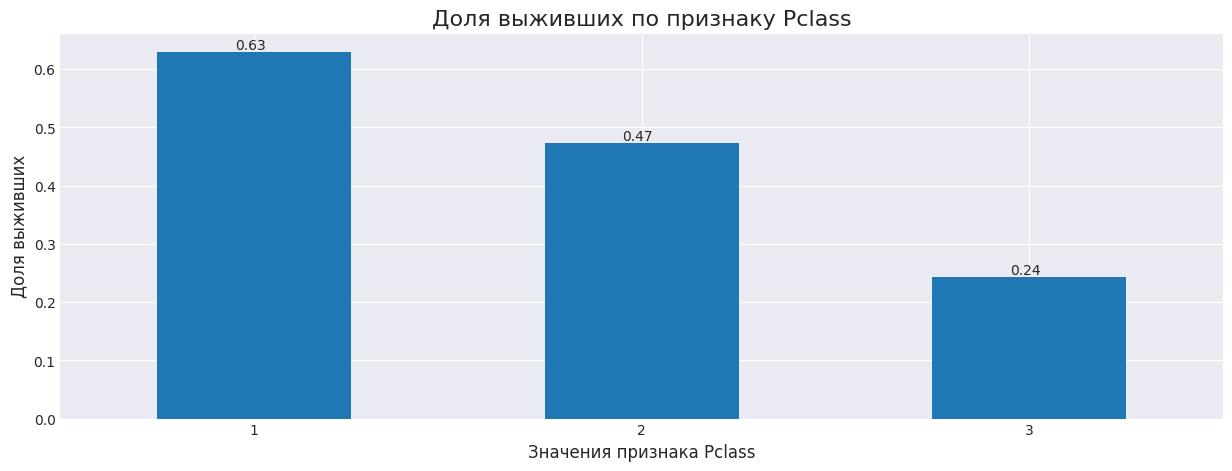

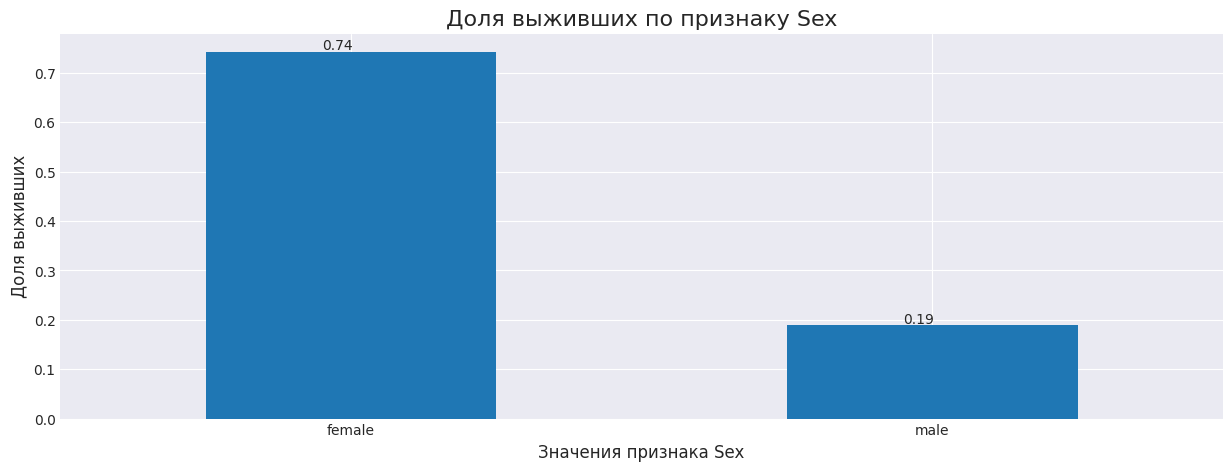

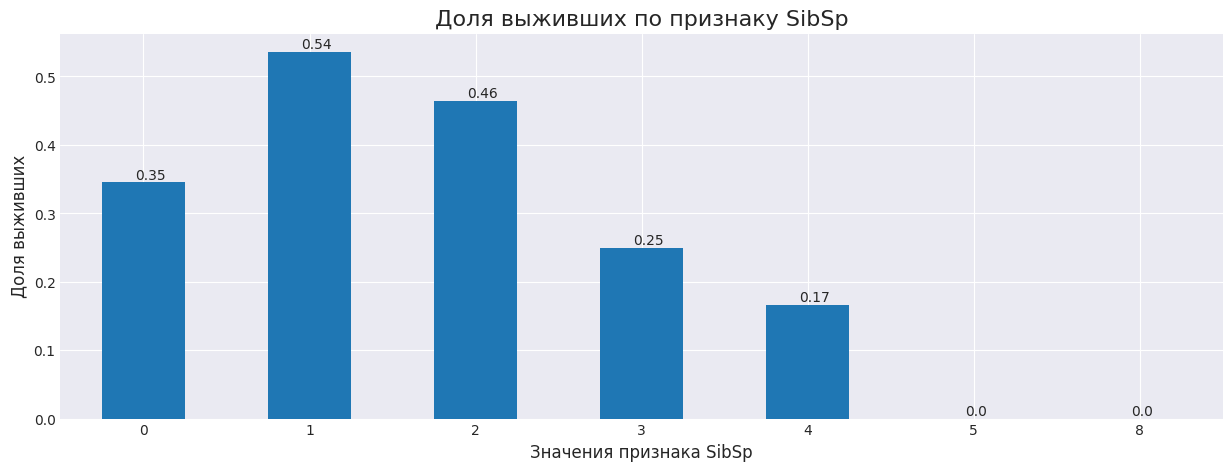

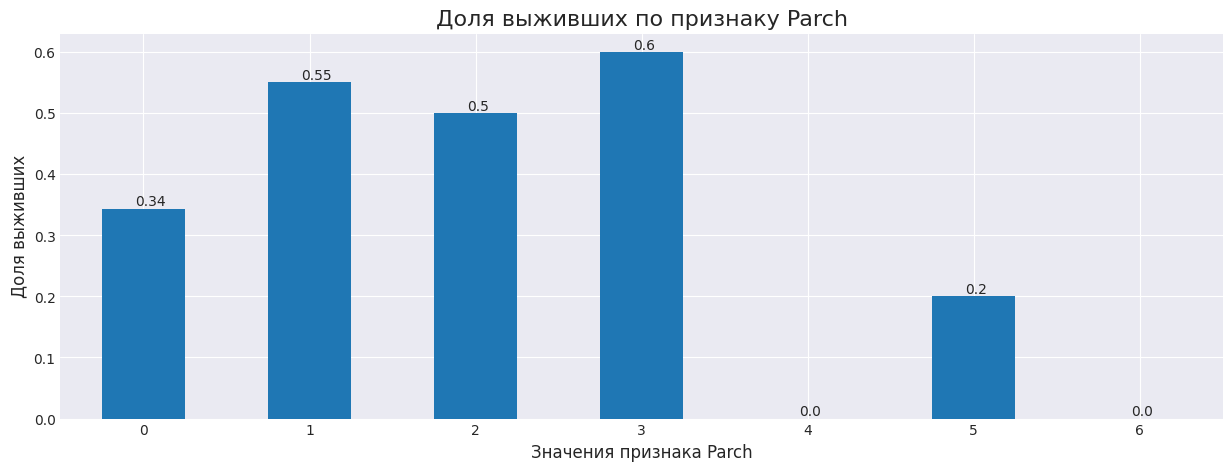

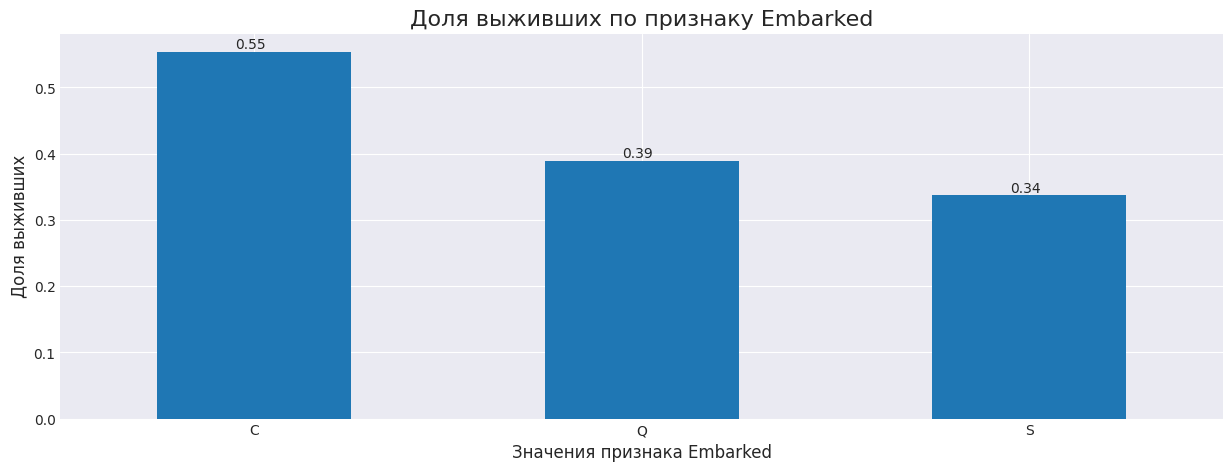

In [19]:
columns_to_look = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

for column in columns_to_look:
    pivot = training_set.pivot_table(index=column, values='Survived', aggfunc='mean')
    
    fig, ax = plt.subplots(figsize=(15,5))
    ax.set_title(f'Доля выживших по признаку {column}', fontdict={'size': 16})
    ax.set_ylabel('Доля выживших', fontdict={'size': 12})
    ax.set_xlabel(column, fontdict={'size': 12})
    
    for cnt in range(pivot.shape[0]):
        value = pivot.iloc[cnt].values[0]
        ax.text(cnt - .05, value + .005, round(value, 2))
        
    pivot.plot(kind='bar', rot=0, grid=True, legend=False, ax=ax) 
    ax.set_xlabel(f'Значения признака {column}', fontdict={'size': 12})
    plt.show()

Видим, что ни один из признаков не стоит убирать из таблицы, т.к. значения доли выживших сильно отличается. Разумеется, различия могуть быть вызваны случайностью, особенно на больших значениях признаков SibSp и Parch, т.к. объектов с такими значениями мало и доля выживших не очень информативна. Но удалить эти признаки мы всё-таки не можем, т.к. значения доли различны.

Видно, что особенно значимое влияние на значение целевого признака оказывает пол пассажира. Довольно значимым признаком так же является класс.

### Исследование пропущенных значений

Используем метод .info(), чтобы увидеть больше информацию о типах данных/структуре в тренировочной выборке.

In [20]:
training_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


Можно увидеть, что значение Age не задано для большого количества записей.
Из 891 строк, возраст Age задан лишь для 714 записей.
Аналогично, номер каюты "Cabin" также пропущены для большого количества записей. Только 204 из 891 записей содержат значения Cabin.

In [21]:
training_set.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Всего 177 записей с пропущенным возрастом (Age), 687 записей с пропущенным значение каюты Cabin и для 2 записей не заданы порты отправления Embarked.

### Исследование отсутствующих значений

Приступим к исследованию отсутствующих значений.

При вызове метода isnull получаем таблицу с булевыми значениями, False - присутствуют данные, True - данные отсутствуют

In [22]:
training_set.isnull().head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False


Для визуализации представленых булевых значений воспользуемся Seaborn heatmap, с помощью чего сможем увидеть где больше всего отсутствующих данных. Желтый цвет нам говорит о пропущенных значениях. Наглядно видно, что много отсутствующих данных в столбце Age и Cabin.

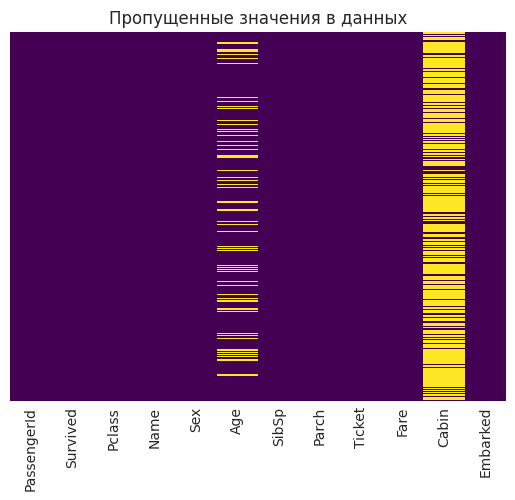

In [23]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Пропущенные значения в данных')
plt.show()

Осталось большое количество отсутствующих данных в столбце Cabin (Каюты), если бы мы использовали этот столбец для анализа, то тогда можно было бы применить способ что бы предугадать пропущеные значения, но столбец нам не нужен, поэтому мы можем его просто отбросить, при помощи кода представленного ниже

In [24]:
training_set.drop('Cabin', axis=1, inplace=True)

Проверим нашу таблицу, и увидим что столбец отсутствует

In [25]:
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


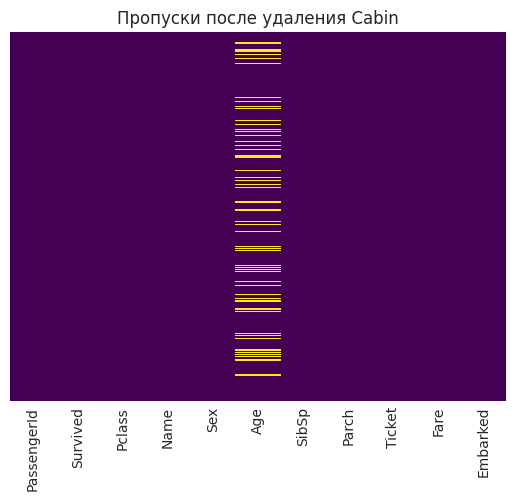

In [26]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Пропуски после удаления Cabin')
plt.show()

Мы видим что осталось одно отсутствующее значение и мы можем легко от него избавиться, код ниже удаляет строки с отсутствующими значениями

In [27]:
training_set.dropna(inplace=True)

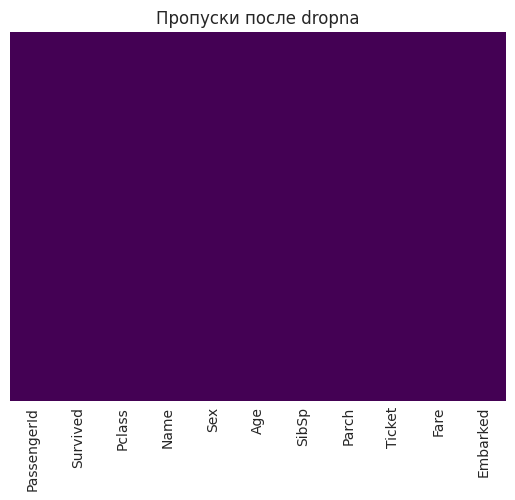

In [28]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Пропуски после dropna')
plt.show()

Перезапустим код и видим что мы не имеем отсутствующих значений. Таким образом мы совершили первый шаг очистки данных, мы очистили наши данные от отсутствующих данных, какие то отсутствующие данные мы заполнили средними значениями, а некоторые просто удалили.

### Преобразование категориальных признаков

Далее мы будем работать с категориальными характеристиками. Нам необходимо конвертировать категориальные характеристики в численные, так как большинство моделей машинного обучения не может работать с текстовыми данными как входными.

Рассмотрим столбец Sex(пол). Мы видим категории male и female, алгоритм машинного не может принимать строку, т.е. мы должны создать еще один столбец в котором будут нули и единицы, т.е. мы должны закодировать эти категории, чтобы алгоритм машинного обучения мог их понять. Это называется создание фиктивной переменной. И то же самое мы сделаем для столбца Embarked (порт прибытия), так как в этом столбце буквы которые представляют города.

Рассмотрим кодирование категорий целочисленными значениями (label encoding). В этом случае уникальные значения категориального признака кодируются целыми числами. Кодирование категорий целочисленными значениями - LabelEncoder, предполагается что значения категорий заменяются целыми числами в случайном порядке

In [29]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [30]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(training_set['Sex'])
cat_enc_le[:10]

array([1, 0, 0, 0, 1, 1, 1, 0, 0, 0])

Выведем уникальные значения данного признака:

In [31]:
training_set['Sex'].unique()

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str

Теперь посмотрим уникальные значения после преобразования:

In [32]:
np.unique(cat_enc_le)

array([0, 1])

С помощью созданного объекта можно выполнить обратное преобразование:

In [33]:
le.inverse_transform([0,1])

array(['female', 'male'], dtype=object)

В зависимости от данных это преобразование может создать новую проблему. Мы перевели набор стран в набор чисел. Но это всего лишь категориальные данные, и между числами на самом деле нет никакой связи. Проблема здесь в том, что, поскольку разные числа в одном столбце, модель неправильно подумает, что данные находятся в каком-то особом порядке — 0 < 1 < 2 Хотя это, конечно, совсем не так.

Поэтому LabelEncoder можно применять с осторожностью. По этому принципу можно преобразовывать бинарные переменные (такие как пол) или переменные, измеренные по ординальной шкале. Но ординальные переменные надо преобразовывать не в случайном порядке, а в строго определенном, в естественном порядке.

Для решения проблемы мы используем OneHotEncoder. Этот кодировщик берёт столбец с категориальными данными, который был предварительно закодирован в признак, и создаёт для него несколько новых столбцов. Числа заменяются на единицы и нули, в зависимости от того, какому столбцу какое значение присуще.

In [34]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(training_set[['Embarked']])
cat_enc_ohe.shape

(712, 3)

То же самое преобразование можно сделать при помощи встроенного в pandas метода get_dummies().

Вызовем метод get_dummies передаем столбец Sex, данный метод конвертирует категориальные переменные в фиктивные переменные, так же они известные как переменные-индикаторы

In [35]:
pd.get_dummies(training_set['Sex'])

,female,male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
885,True,False
886,False,True
887,True,False
889,False,True


Получаем такой результат, т.е. у нас два столбца и 0 и 1 в качестве значений, можно расценивать как булевы значения, 0 это False, 1 это True. Первая строка говорит нам о том что male = 1 означает что человек был мужского пола.

Но мы получаем проблему: один столбец идеально предсказывает второй столбец, т.е. если мы зададим такие входные данные в алгоритм машинного обучения, то он поймет что в случае если в одном столбце ноль в другом обязательно будет 1. Эта проблема называется мультиколлинеарностью. Это запутывает алгоритм. Решением будет удаление одного столбца.

In [36]:
sex = pd.get_dummies(training_set['Sex'], drop_first=True)
sex.head()

,male
0,True
1,False
2,False
3,False
4,True


Сделаем тоже самое для столбца Embarked

In [37]:
embark = pd.get_dummies(training_set['Embarked'], drop_first=True)
embark.head()

,Q,S
0,False,True
1,False,False
2,False,True
3,False,True
4,False,True


Добавим вновь созданные столбцы sex, embark в наше множество данных при помощи метода pd.concat мы добавляем список указываем training_set и добавляем столбцы sex, embark и указываем еще один параметр axis=1 что бы указать что это будут столбцы.

In [38]:
training_set = pd.concat([training_set, sex, embark], axis=1)
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,True,False,True


Удаляем ненужные столбцы

In [39]:
training_set.drop(['Sex', 'Embarked', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [40]:
training_set.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


Таким образом мы получили итоговый набор данных, подготовленный к машинному обучению. Это набор данных удовлетворяет всем условиям чистых данных, и при этом содержит всю информацию из первоначального датасета.

### Контрольные вопросы

**1. Какие основные виды визуализации вы знаете? Какие у них области применения?**

Основные виды визуализации и их области применения:

- **Гистограмма** — для анализа распределения одной непрерывной переменной (например, возраста или стоимости билета). Позволяет увидеть, где сосредоточены основные значения, есть ли выбросы и асимметрия.

- **Столбчатая диаграмма (countplot)** — для анализа распределения одной дискретной или категориальной переменной (например, количество пассажиров по классам или по полу). Показывает частоту каждого значения.

- **Круговая диаграмма (pie chart)** — для отображения долей категориальных переменных. Применяется, когда нужно показать процентное соотношение частей в целом.

- **Диаграмма рассеяния (scatter plot)** — для анализа совместного распределения двух непрерывных переменных. Позволяет увидеть характер связи (линейная, нелинейная, отсутствие) и наличие выбросов.

- **Ящик с усами (boxplot)** — для сравнения распределения непрерывной переменной по категориям. Показывает медиану, квартили и выбросы. Хорошо подходит для выявления различий между группами.

- **Тепловая карта (heatmap)** — для визуализации матрицы корреляции или пропущенных значений. Позволяет быстро оценить силу связей между признаками.

- **Совместная гистограмма (jointplot)** — для одновременного анализа двух непрерывных переменных: показывает распределение каждой и их совместное рассеяние.

**2. Какие типы визуализации больше всего подходят для анализа совместного распределения двух непрерывных переменных?**

Для анализа совместного распределения двух непрерывных переменных лучше всего подходят:

- **Диаграмма рассеяния (scatter plot)** — основной инструмент. Каждая точка соответствует одному наблюдению, координаты — значения двух признаков. Позволяет увидеть направление, форму и тесноту связи между переменными.

- **Jointplot** из библиотеки Seaborn — комбинирует диаграмму рассеяния с гистограммами каждой переменной по краям, что даёт полное представление о распределениях.

- **Тепловая карта корреляционной матрицы** — полезна, когда нужно оценить силу линейной связи между несколькими парами непрерывных переменных одновременно.

- **Гексагональное сглаживание (hexbin plot)** — альтернатива диаграмме рассеяния при большом количестве точек, когда точка на точке мешает восприятию.

**3. Какие типы визуализации больше всего подходят для анализа совместного распределения двух дискретных переменных?**

Для анализа совместного распределения двух дискретных (категориальных) переменных лучше всего подходят:

- **Сгруппированная столбчатая диаграмма** — позволяет сравнить частоты одной категориальной переменной в разрезе значений другой. Например, на методичке показан график зависимости выживаемости от класса с разбивкой по полу.

- **Сводная таблица (pivot table) с тепловой картой** — значениями в таблице выступают частоты или доли, цветовая заливка помогает быстро оценить, какие комбинации встречаются чаще.

- **Диаграмма с накоплением (stacked bar chart)** — показывает доли каждой категории внутри другой, удобна для сравнения относительных распределений.

- **Мозаичный график (mosaic plot)** — площадь прямоугольников пропорциональна частоте комбинаций, хорошо иллюстрирует независимость или зависимость признаков.

**4. Как лучше всего построить совместное распределение дискретной и непрерывной переменной?**

Для анализа совместного распределения дискретной (категориальной) и непрерывной переменной лучше всего подходят:

- **Ящик с усами (boxplot)** — оптимальный выбор. На одной оси откладываются категории, на другой — значения непрерывной переменной. Позволяет сравнить медиану, разброс и выбросы для каждой категории. В методичке такой график использован для анализа возраста в зависимости от класса пассажира.

- **Violin plot** — улучшенная версия boxplot, которая также показывает плотность распределения внутри каждой категории.

- **Совмещённые гистограммы** — несколько гистограмм (по одной на каждую категорию) на одном графике с наложением или рядом.

- **График средних с доверительными интервалами** — полезен, когда нужно показать не всё распределение, а только типичное значение и его статистическую надёжность.

**5. Как лучше всего построить совместное распределение двух непрерывных и одной дискретной переменной?**

Для анализа совместного распределения двух непрерывных и одной дискретной переменной лучше всего подходят:

- **Диаграмма рассеяния с цветовой кодировкой** — на плоскости откладываются две непрерывные переменные, а цвет точек соответствует значению дискретной. В методичке это показано на примере KernelPCA, где точки разных классов окрашены в разные цвета.

- **Фасетная сетка (facet grid / pair plot с hue)** — создаётся несколько диаграмм рассеяния, каждая для отдельной категории дискретной переменной, либо все на одном графике с разными маркерами.

- **3D-диаграмма рассеяния** — оси X и Y — непрерывные переменные, ось Z или цвет — дискретная. Используется с осторожностью, так как 3D-визуализация может искажать восприятие.

- **Тепловая карта для каждой категории отдельно** — можно построить отдельные диаграммы рассеяния или контурные графики плотности для каждого значения дискретной переменной и расположить их сеткой.

**6. Как лучше всего построить совместное распределение двух дискретных и одной непрерывной переменной?**

Для анализа совместного распределения двух дискретных и одной непрерывной переменной лучше всего подходят:

- **Сгруппированные ящики с усами (grouped boxplot)** — на оси X откладываются значения первой дискретной переменной, а внутри каждой группы — ящики для значений второй дискретной переменной. Например, можно показать распределение возраста для каждого класса, а внутри — для мужчин и женщин отдельно.

- **Тепловая карта с наложением статистики** — на сетке из двух дискретных переменных в каждой ячейке отображается среднее или медианное значение непрерывной переменной, а цвет показывает величину.

- **Фасетная сетка boxplot или violin plot** — создаётся несколько графиков: каждый для одного значения первой дискретной переменной, а на графике — ящики для второй дискретной.

- **Диаграмма рассеяния с джиттером (jitter plot) и цветом** — точки слегка размываются, чтобы не сливались, а цвет кодирует одну из дискретных переменных. Компактно, но при большом количестве данных может стать нечитаемым.

- **Сводная таблица с агрегацией**, визуализированная как тепловая карта — для компактного представления средних значений непрерывной переменной по комбинациям двух дискретных.